In [2]:
# Libraries
import sys
sys.path.append('../')

import numpy as np
import matplotlib.pyplot as plt
import json
from data_processors import *
from scipy.stats import sem, t
import os
import copy
import math
import imageio
import random

In [3]:
# Funzione per caricare i dati da un percorso
def load_trials(base_path, n_exp):
    trial_performances = []
    for i in range(n_exp):
        trial_path = os.path.join(base_path, f"trial_{i}")
        if os.path.isdir(trial_path):
            try:
                file_path = os.path.join(trial_path, "results.json")
                with open(file_path, 'r') as file:
                    data = json.load(file)
                    trial_performances.append(data["performance"])
            except (FileNotFoundError, json.JSONDecodeError) as e:
                print(f"Errore nel leggere {file_path}: {e}")
    return np.array(trial_performances)  # Converte in array per calcoli successivi

## BASELINE : Policy Gradient (gpomdp) linear policy FRICTION 0

In [7]:
paths = [
    "/home/tedeschi_bpo/learn_RL/results/TEST_NUOVI/BASE_FRIC0_reinforce-test_12_15-14_30_PG_600_cartpole_200_099_adam_001_100_noclip__linear_gaussian_4_std_05_noise_00",
    "/home/tedeschi_bpo/learn_RL/results/TEST_NUOVI/BASE_FRIC0_reinforce-test_12_15-14_32_PG_600_cartpole_200_099_adam_001_100_noclip__linear_gaussian_4_std_1_noise_00"
]
# Lista per memorizzare le performance per ogni set
all_performances = []

for path in paths:
    performances = load_trials(path, n_exp=2)
    if performances.size > 0:
        all_performances.append(performances)

lab = ['rf std 0.5', 'rf std 1']
print(len(all_performances))

2


66.79704976658455
65.33433178241323


<Figure size 640x480 with 0 Axes>

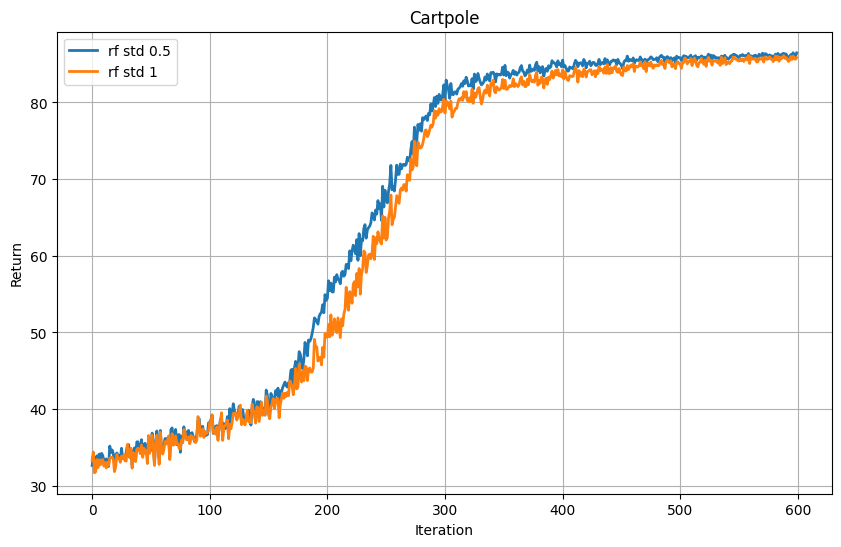

In [8]:
# Plot dei grafici
plt.clf()
# plt.figure(figsize=(6.5, 4.5))
plt.figure(figsize=(10, 6))

for i, performances in enumerate(all_performances):
    if performances.size > 0:
         # Calcola la media e gli intervalli di confidenza
        mean_performance = np.mean(performances, axis=0)
        std_performance = np.std(performances, axis=0)

        # Plot della curva media
        plt.plot(mean_performance, linewidth=2, label = lab[i])

        print(np.mean(mean_performance))

# Etichette e titolo
plt.title("Cartpole")
plt.xlabel("Iteration")
plt.ylabel("Return")

plt.legend()
plt.grid()

plt.show()

## ATTRITO 0.3 da parametri ottimi policy gradient base

In [11]:
paths = [
    "/home/tedeschi_bpo/learn_RL/results/TEST_NUOVI/RF_FRIC_0.3-test_12_15-14_50_PG_400_cartpole_friction_200_099_adam_001_100_noclip__linear_gaussian_4_std_05_noise_00"
]
# Lista per memorizzare le performance per ogni set
all_performances = []

for path in paths:
    performances = load_trials(path, n_exp=2)
    if performances.size > 0:
        all_performances.append(performances)

lab = ['rf fric 0.3 from optimal params']
print(len(all_performances))

1


86.1310653801197


<Figure size 640x480 with 0 Axes>

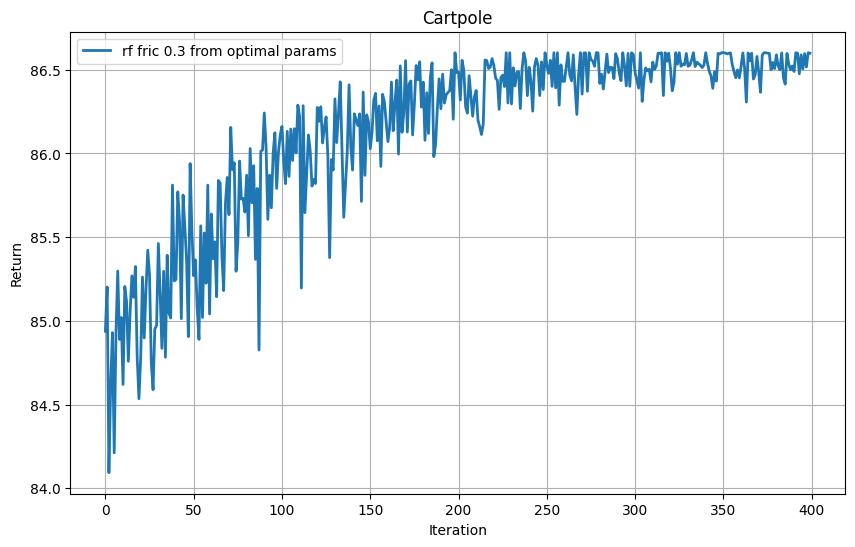

In [12]:
# Plot dei grafici
plt.clf()
# plt.figure(figsize=(6.5, 4.5))
plt.figure(figsize=(10, 6))

for i, performances in enumerate(all_performances):
    if performances.size > 0:
         # Calcola la media e gli intervalli di confidenza
        mean_performance = np.mean(performances, axis=0)
        std_performance = np.std(performances, axis=0)

        # Plot della curva media
        plt.plot(mean_performance, linewidth=2, label = lab[i])

        print(np.mean(mean_performance))

# Etichette e titolo
plt.title("Cartpole")
plt.xlabel("Iteration")
plt.ylabel("Return")

plt.legend()
plt.grid()

plt.show()

## ATTRITO 0.3 da parametri ottimi BPO base

In [23]:
paths = [
    "/home/tedeschi_bpo/learn_RL/results/TEST_NUOVI/RF_FRIC_0.3-test_12_15-14_50_PG_400_cartpole_friction_200_099_adam_001_100_noclip__linear_gaussian_4_std_05_noise_00",
    "/home/tedeschi_bpo/learn_RL/results/TEST_NUOVI/BPO_BASE_FRIC_0.3-test_12_15-14_55_PG_400_cartpole_friction_200_099_adam_001_100_noclip__linear_gaussian_4_std_05_noise_00",
]
# Lista per memorizzare le performance per ogni set
all_performances = []

for path in paths:
    performances = load_trials(path, n_exp=2)
    if performances.size > 0:
        all_performances.append(performances)

lab = ['rf fric 0.3 from optimal params', 'bpo fric 0.3 from optimal params', 'bpo std 1']
print(len(all_performances))

2


86.1310653801197
86.08456211943478


<Figure size 640x480 with 0 Axes>

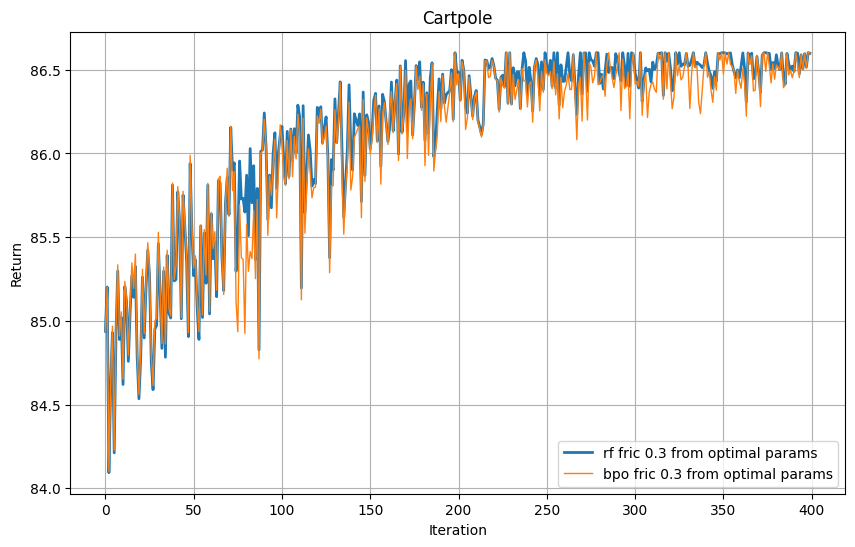

In [24]:
# Plot dei grafici
plt.clf()
# plt.figure(figsize=(6.5, 4.5))
plt.figure(figsize=(10, 6))

for i, performances in enumerate(all_performances):
    if performances.size > 0:
         # Calcola la media e gli intervalli di confidenza
        mean_performance = np.mean(performances, axis=0)
        std_performance = np.std(performances, axis=0)

        # Plot della curva media
        plt.plot(mean_performance, linewidth=2-i, label = lab[i])

        print(np.mean(mean_performance))

# Etichette e titolo
plt.title("Cartpole")
plt.xlabel("Iteration")
plt.ylabel("Return")

plt.legend()
plt.grid()

plt.show()

## Behavioral con paraemtro in più

In [10]:
paths = [
    "/home/tedeschi_bpo/learn_RL/results/TEST_NUOVI/RF_FRIC_0.3-test_12_15-14_50_PG_400_cartpole_friction_200_099_adam_001_100_noclip__linear_gaussian_4_std_05_noise_00",
    "/home/tedeschi_bpo/learn_RL/results/TEST_NUOVI/BPO_BASE_FRIC_0.3-test_12_15-14_55_PG_400_cartpole_friction_200_099_adam_001_100_noclip__linear_gaussian_4_std_05_noise_00",
    "/home/tedeschi_bpo/learn_RL/results/TEST_NUOVI/BPO_PARAMETRO_IN_PIU_FRIC_0.3-test_12_15-16_03_PG_400_cartpole_friction_200_099_adam_001_100_noclip__linear_gaussian_4_std_05_noise_00",
    #"/home/tedeschi_bpo/learn_RL/results/TEST_NUOVI/BPO_PARAMETRO_IN_PIU_MASK_FRIC_0.3-test_12_18-11_19_PG_400_cartpole_friction_200_099_adam_001_100_noclip__linear_gaussian_4_std_05_noise_00"
]
# Lista per memorizzare le performance per ogni set
all_performances = []

for path in paths:
    performances = load_trials(path, n_exp=1)
    if performances.size > 0:
        all_performances.append(performances)

lab = ['rf fric 0.3 from optimal params', 'bpo fric 0.3 from optimal params', 'bpo parametro in più']
print(len(all_performances))

3


86.1310653801197
86.08456211943478
86.0933630443854


<Figure size 640x480 with 0 Axes>

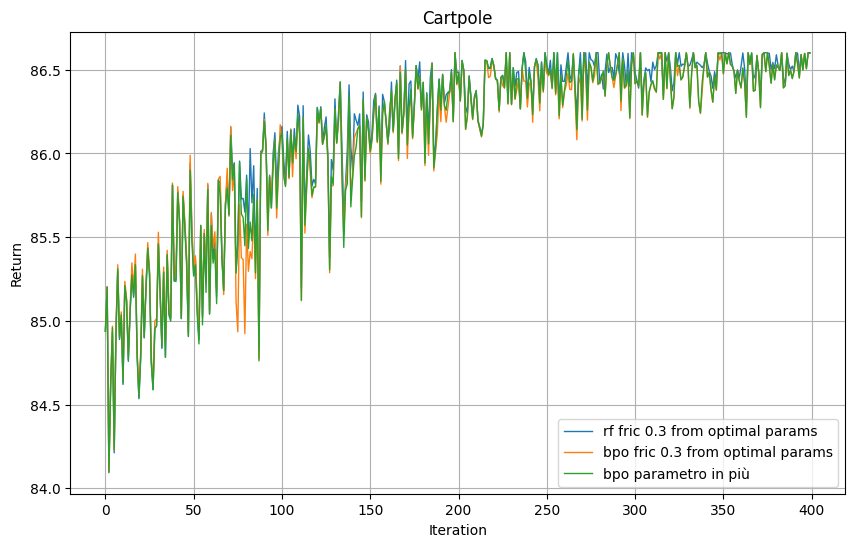

In [11]:
# Plot dei grafici
plt.clf()
# plt.figure(figsize=(6.5, 4.5))
plt.figure(figsize=(10, 6))

for i, performances in enumerate(all_performances):
    if performances.size > 0:
         # Calcola la media e gli intervalli di confidenza
        mean_performance = np.mean(performances, axis=0)
        std_performance = np.std(performances, axis=0)

        # Plot della curva media
        plt.plot(mean_performance, linewidth=1, label = lab[i])

        print(np.mean(mean_performance))

# Etichette e titolo
plt.title("Cartpole")
plt.xlabel("Iteration")
plt.ylabel("Return")

plt.legend()
plt.grid()

plt.show()

In [33]:
def load_trials_states(base_path, n_exp):
    all_states = []  # will hold arrays of shape (iterations, 5, 100, 2)

    for i in range(n_exp):
        trial_path = os.path.join(base_path, f"trial_{i}")

        if os.path.isdir(trial_path):
            try:
                file_path = os.path.join(trial_path, "results.json")
                with open(file_path, 'r') as file:
                    data = json.load(file)

                    # expect data["states"] to be a nested list structure
                    states = np.array(data["states"])
                    all_states.append(states)

            except (FileNotFoundError, json.JSONDecodeError, KeyError) as e:
                print(f"Errore nel leggere {file_path}: {e}")

    return np.array(all_states)

In [35]:
paths = [
    "/home/tedeschi_bpo/learn_RL/results/TEST_NUOVI/BPO_BASE_FRIC_0.3-test_12_15-14_55_PG_400_cartpole_friction_200_099_adam_001_100_noclip__linear_gaussian_4_std_05_noise_00",
    "/home/tedeschi_bpo/learn_RL/results/TEST_NUOVI/BPO_PARAMETRO_IN_PIU_FRIC_0.3-test_12_15-16_22_PG_400_cartpole_friction_200_099_adam_001_100_noclip__linear_gaussian_4_std_05_noise_00"
]

# Lista per memorizzare gli stati per ogni set
all_states = []

for path in paths:
    states = load_trials_states(path, n_exp=10)
    if states.size > 0:  # check that something was loaded
        all_states.append(states)

# Labels for each set (matching your previous code)
lab = ['rf from opt', 'bpo param + 1 from opt']

print(len(all_states))  # should match the number of loaded sets

2


/home/tedeschi_bpo/miniconda3/envs/RlEnv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


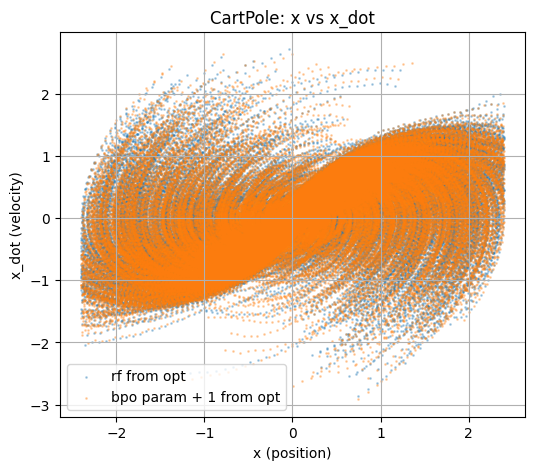

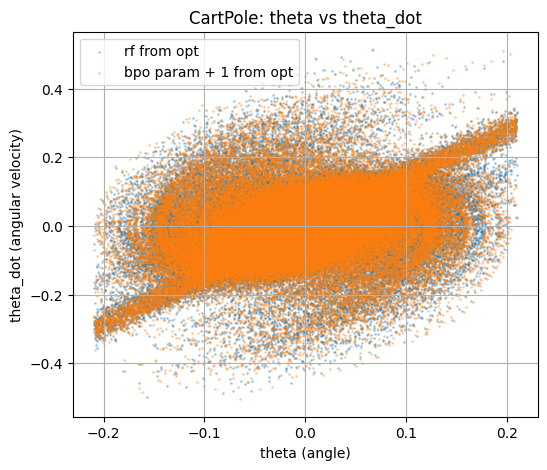

In [36]:
import matplotlib.pyplot as plt
import numpy as np

# --- Plot 1: x vs x_dot ---
plt.figure(figsize=(6, 5))

for i, states_alg in enumerate(all_states):
    # Flatten: (n_exp * iterations * T, 4)
    states_flat = states_alg.reshape(-1, 4)

    plt.scatter(
        states_flat[:, 0],  # x
        states_flat[:, 1],  # x_dot
        s=1, alpha=0.3, label=lab[i]
    )

plt.xlabel('x (position)')
plt.ylabel('x_dot (velocity)')
plt.title('CartPole: x vs x_dot')
plt.legend()
plt.grid(True)
plt.show()


# --- Plot 2: theta vs theta_dot ---
plt.figure(figsize=(6, 5))

for i, states_alg in enumerate(all_states):
    states_flat = states_alg.reshape(-1, 4)

    plt.scatter(
        states_flat[:, 2],  # theta
        states_flat[:, 3],  # theta_dot
        s=1, alpha=0.3, label=lab[i]
    )

plt.xlabel('theta (angle)')
plt.ylabel('theta_dot (angular velocity)')
plt.title('CartPole: theta vs theta_dot')
plt.legend()
plt.grid(True)
plt.show()


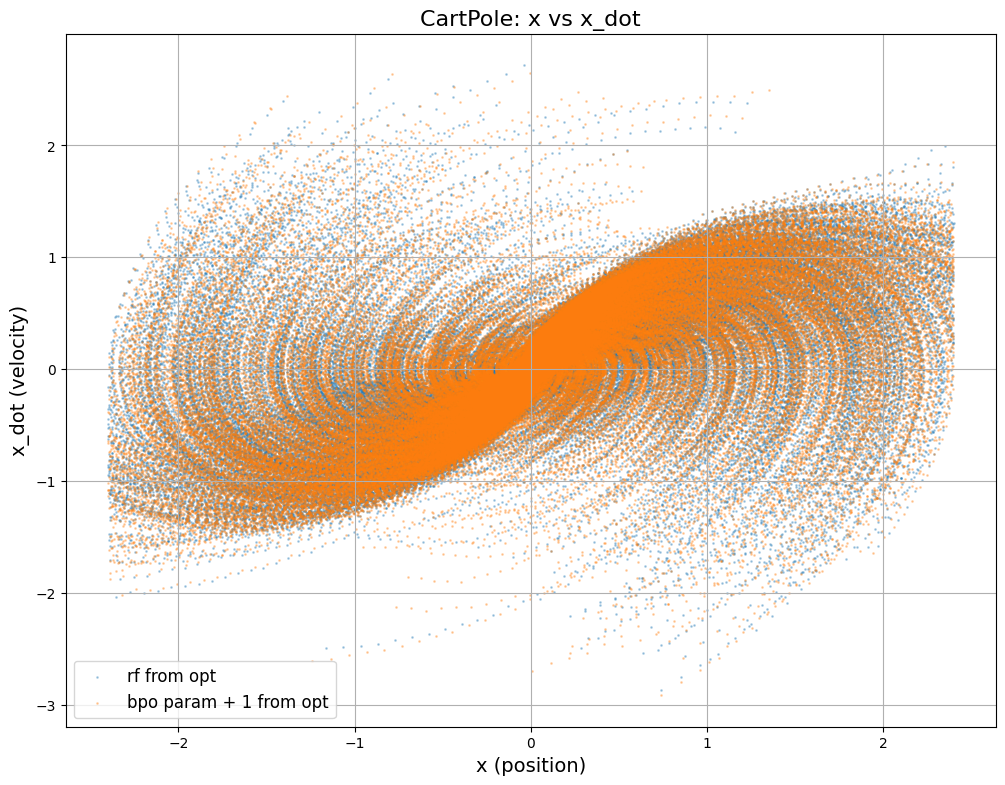

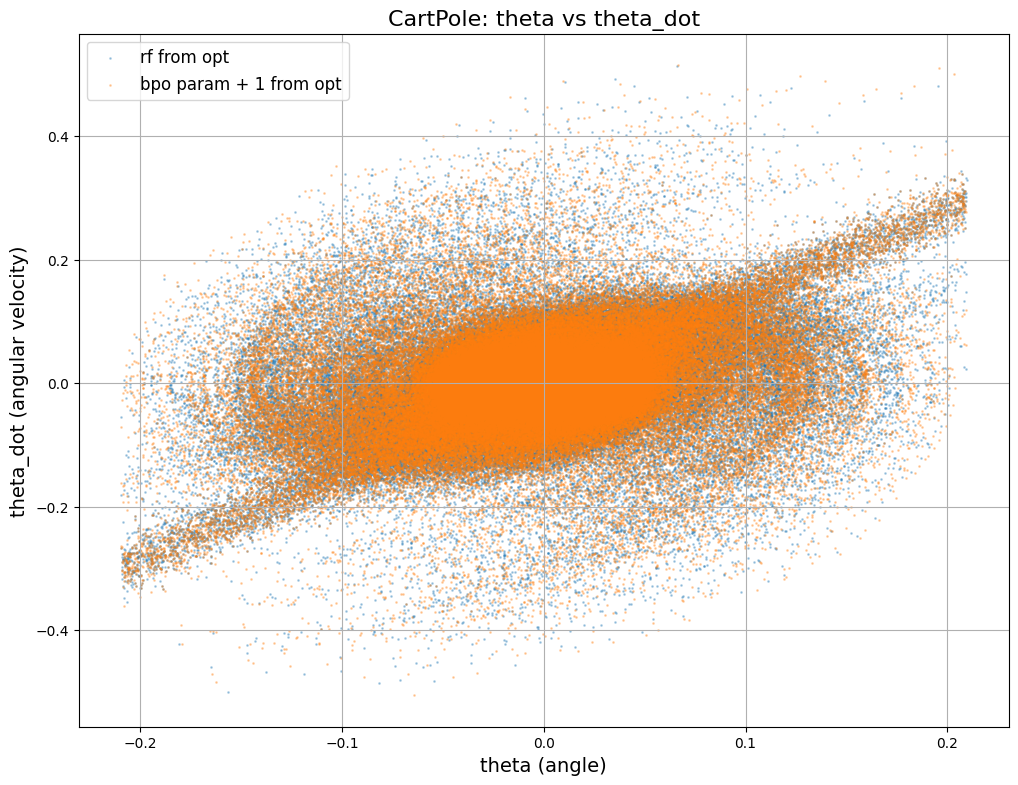

In [37]:
import matplotlib.pyplot as plt
import numpy as np

# --- Plot 1: x vs x_dot ---
plt.figure(figsize=(12, 9))  # bigger figure

for i, states_alg in enumerate(all_states):
    states_flat = states_alg.reshape(-1, 4)

    plt.scatter(
        states_flat[:, 0],  # x
        states_flat[:, 1],  # x_dot
        s=1, alpha=0.3, label=lab[i]
    )

plt.xlabel('x (position)', fontsize=14)
plt.ylabel('x_dot (velocity)', fontsize=14)
plt.title('CartPole: x vs x_dot', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()


# --- Plot 2: theta vs theta_dot ---
plt.figure(figsize=(12, 9))  # bigger figure

for i, states_alg in enumerate(all_states):
    states_flat = states_alg.reshape(-1, 4)

    plt.scatter(
        states_flat[:, 2],  # theta
        states_flat[:, 3],  # theta_dot
        s=1, alpha=0.3, label=lab[i]
    )

plt.xlabel('theta (angle)', fontsize=14)
plt.ylabel('theta_dot (angular velocity)', fontsize=14)
plt.title('CartPole: theta vs theta_dot', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()


## SCRIPT COSI MI RICORD0



### 1) SCRIPT PER PARAMETRI OTTIMI
#!/bin/bash

python3 /home/tedeschi_bpo/learn_RL/run_ns.py \
    --dir /home/tedeschi_bpo/learn_RL/results/TEST_NUOVI/BASE_FRIC0_reinforce-test \
    --ite 600 --std 0.5 --env cartpole \
    --horizon 200 --batch 100 --gamma 0.99 \
    --n_trial 1 --pol linear_gaussian --n_jobs 20 \
    --lr 1e-2 --lr_strategy adam --estimator GPOMDP \
    --verbose 1 --baseline peters --starting_seed 0 \
    --algorithm on_policy \
    --behavioural_std 0.5 \
    --debug --friction 0.0 --animate

### 2) SCRIPT ATTRITO 0.3 da parametri ottimi policy gradient base

#!/bin/bash

python3 /home/tedeschi_bpo/learn_RL/run_ns.py \
    --dir /home/tedeschi_bpo/learn_RL/results/TEST_NUOVI/RF_FRIC_0.3-test \
    --ite 400 --std 0.5 --env cartpole_friction \
    --horizon 200 --batch 100 --gamma 0.99 \
    --n_trial 1 --pol linear_gaussian --n_jobs 20 \
    --lr 1e-2 --lr_strategy adam --estimator GPOMDP \
    --verbose 1 --baseline peters --starting_seed 0 \
    --algorithm on_policy \
    --behavioural_std 0.5 \
    --debug --friction 0.3 \
    --params_dir /home/tedeschi_bpo/learn_RL/results/TEST_NUOVI/BASE_FRIC0_reinforce-test_12_15-14_30_PG_600_cartpole_200_099_adam_001_100_noclip__linear_gaussian_4_std_05_noise_00/trial_0/policy_params.npy

### 3) SCRIPT ATTRITO 0.3 da parametri ottimi bpo base
#!/bin/bash

python3 /home/tedeschi_bpo/learn_RL/run_ns.py \
    --dir /home/tedeschi_bpo/learn_RL/results/TEST_NUOVI/BPO_BASE_FRIC_0.3-test \
    --ite 400 --std 0.5 --env cartpole_friction \
    --horizon 200 --batch 100 --gamma 0.99 \
    --n_trial 1 --pol linear_gaussian --n_jobs 20 \
    --lr 1e-2 --lr_strategy adam --estimator GPOMDP \
    --verbose 1 --baseline peters --starting_seed 0 \
    --algorithm off_policy \
    --behavioural_std 0.5 \
    --debug --friction 0.3 \
    --params_dir /home/tedeschi_bpo/learn_RL/results/TEST_NUOVI/BASE_FRIC0_reinforce-test_12_15-14_30_PG_600_cartpole_200_099_adam_001_100_noclip__linear_gaussian_4_std_05_noise_00/trial_0/policy_params.npy




















